# 07. Model Evaluation

## 📚 Learning Objectives

By completing this notebook, you will:
- Compute accuracy, precision, recall, F1
- Use cross-validation and learning curves
- Interpret evaluation plots and metrics

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 2 (cross-validation, learning curves) and Unit 3, lesson 01 (precision, recall, F1) — the same evaluation discipline applied to this unit's models.

**Used later in:** Course 05 — Unit 4, lesson 08 (tuning is evaluation in a loop) and Course 12 (AIAT 126) — Unit 4.

---


## 🎯 The case: the $1,000,000 algorithm Netflix never shipped

In October 2006 Netflix offered **$1 million** to anyone who could improve its Cinematch
recommender's RMSE by 10%. Thousands of teams competed for three years. On **21 September
2009** the prize went to **BellKor's Pragmatic Chaos**, with a **10.06% improvement**.

Netflix did not deploy the winning solution. The winning entry was an ensemble of over a
hundred models, and the engineering effort required to run it in production was not
justified by the gain the business actually cared about.

The competition was a triumph of evaluation discipline — held-out data, a public
leaderboard, a locked-in metric — and a demonstration of its limit. **The metric that
selects your model is not the metric your organisation is paid on.** Booking.com made the
same point with data rather than anecdote: in *"150 Successful Machine Learning Models: 6
Lessons Learned at Booking.com"* (KDD 2019), Bernardi, Mavridis and Estevez report on
around 150 customer-facing models validated by randomised controlled trials, and one of
their six lessons is precisely that **offline model performance is not business
performance**.

**What goes wrong without this lesson.** You are about to measure a single held-out score
against a 5-fold cross-validated one and see the spread: **R² = 0.5784 ± 0.0489** across
folds. That ±0.05 is the amount by which a single split could have flattered or damned the
same model. Any comparison of two models closer together than that is noise reported as a
result.


## The Story

**BEFORE**: You know how to build ML models, but don't know how to properly evaluate their performance beyond accuracy.

**AFTER**: You'll master comprehensive model evaluation with cross-validation, precision, recall, F1-score, and learning curves!

**Why this matters**: Proper model evaluation is essential for building reliable, production-ready ML systems!

---

# Unit 4 - Example 7: Model Evaluation

## 🔗 Solving the Problem from Example 6

**Remember the dead end from Example 6?**
- We learned to build classification models
- But we discovered accuracy alone can be misleading
- We need comprehensive evaluation beyond just accuracy

**This notebook solves that problem!**
- We'll learn **comprehensive evaluation metrics** (precision, recall, F1, AUC)
- We'll learn **cross-validation** for robust performance estimation
- We'll learn **learning curves** to understand model behavior

**This solves the evaluation problem from Example 6!**

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Trained model
- Test set

**Outputs:** What you'll see when you run the cells

- Metrics (accuracy, precision, recall, etc.)
- Plots

---

In [1]:
# Step 1: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     KFold, learning_curve)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                             precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.preprocessing import StandardScaler

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("=" * 70)
print("Example 7: Model Evaluation")
print("=" * 70)
print("\n📚 Prerequisites: Examples 04–06 completed, ML model knowledge")
print("🔗 This is Example 7 in Unit 4 - model evaluation")
print("🎯 Goal: Master model evaluation with cross-validation and metrics")

Example 7: Model Evaluation

📚 Prerequisites: Examples 04–06 completed, ML model knowledge
🔗 This is Example 7 in Unit 4 - model evaluation
🎯 Goal: Master model evaluation with cross-validation and metrics


1. CROSS-VALIDATION


In [2]:
# WHAT: Load real California housing data and run 5-fold cross-validation on a linear model.
# WHY: Five scores from five different splits estimate performance AND its variability - one split can mislead.

print("\n1. Cross Validation")
print("-" * 70)

from sklearn.datasets import fetch_california_housing

# Real data: 20,640 California census block groups (1990 census).
# We take 5,000 so the learning-curve and grid-search cells below stay fast.
housing = fetch_california_housing(as_frame=True)
house = housing.frame.sample(n=5000, random_state=42)
HOUSE_FEATURES = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                  'Population', 'AveOccup', 'Latitude', 'Longitude']
X = house[HOUSE_FEATURES].values
y = house['MedHouseVal'].values          # median house value in $100,000s
print(f"Real dataset: {len(X):,} census block groups x {X.shape[1]} features")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

# K-Fold Cross-Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='r2')
print(f"\n5-Fold Cross-Validation R² Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nMean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"Single hold-out test R²: {r2_score(y_test, model.predict(X_test)):.4f}")
print("\n💡 The folds disagree by several R² points. On real, uneven data a single")
print("   split is a lottery ticket; the CV mean and spread are the honest report.")


1. Cross Validation
----------------------------------------------------------------------
Real dataset: 5,000 census block groups x 8 features

5-Fold Cross-Validation R² Scores:
  Fold 1: 0.5995
  Fold 2: 0.5848
  Fold 3: 0.5488
  Fold 4: 0.6080
  Fold 5: 0.5509

Mean CV Score: 0.5784 (+/- 0.0489)
Single hold-out test R²: 0.6289

💡 The folds disagree by several R² points. On real, uneven data a single
   split is a lottery ticket; the CV mean and spread are the honest report.


2. LEARNING CURVES




2. Learning Curves
----------------------------------------------------------------------


✓ Learning curves saved
  At 320 training blocks:  train R² 0.632 | validation R² 0.574
  At 3200 training blocks: train R² 0.605 | validation R² 0.575
  Final train-validation gap: 0.030

💡 Both curves flatten and nearly meet. A linear model on these eight
   features is UNDERfitting, not overfitting - more rows will not help;
   a more flexible model or better features would.


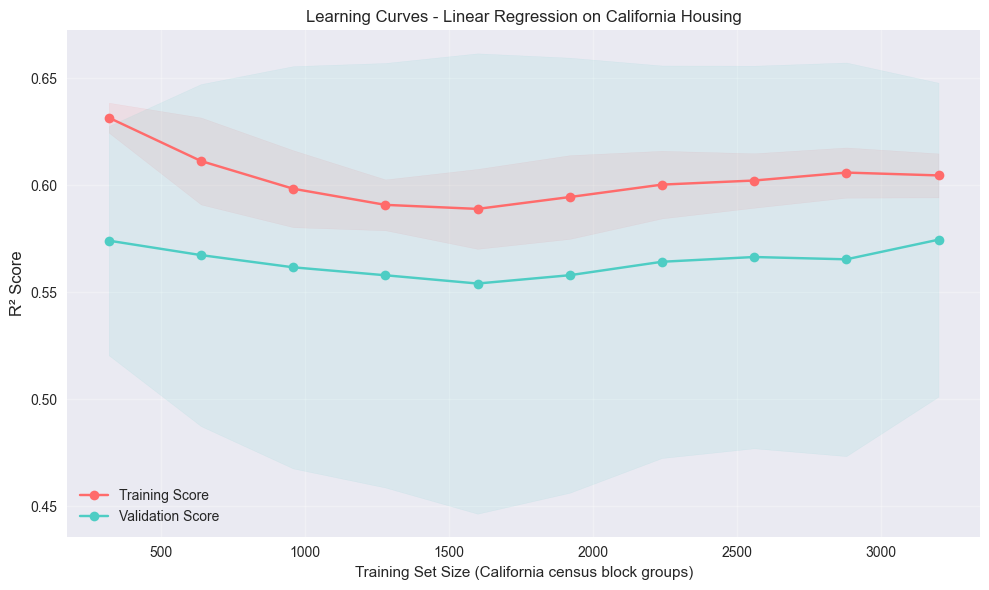

In [3]:
# WHAT: Plot learning curves - score vs training-set size for train and validation.
# WHY: The gap between the two curves diagnoses overfitting; converged flat curves say more data will not help.

print("\n\n2. Learning Curves")
print("-" * 70)
train_sizes, train_scores, val_scores = learning_curve(
    model, X_train, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='r2')
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#FF6B6B', label='Training Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='#FF6B6B')
plt.plot(train_sizes, val_mean, 'o-', color='#4ECDC4', label='Validation Score')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='#4ECDC4')
plt.xlabel('Training Set Size (California census block groups)')
plt.ylabel('R² Score', fontsize=12)
plt.title('Learning Curves - Linear Regression on California Housing')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('12_learning_curves.png', dpi=300, bbox_inches='tight')
print("✓ Learning curves saved")
print(f"  At {int(train_sizes[0])} training blocks:  train R² {train_mean[0]:.3f} | "
      f"validation R² {val_mean[0]:.3f}")
print(f"  At {int(train_sizes[-1])} training blocks: train R² {train_mean[-1]:.3f} | "
      f"validation R² {val_mean[-1]:.3f}")
gap = train_mean[-1] - val_mean[-1]
print(f"  Final train-validation gap: {gap:.3f}")
print("\n💡 Both curves flatten and nearly meet. A linear model on these eight")
print("   features is UNDERfitting, not overfitting - more rows will not help;")
print("   a more flexible model or better features would.")
plt.show()
plt.close()

3. MULTIPLE METRICS EVALUATION


In [4]:
# WHAT: Fit a classifier on the real Titanic manifest and compute accuracy, precision, recall and F1.
# WHY: Each metric answers a different question - precision: 'when it says yes, is it right?'; recall: 'does it find every yes?'.

print("\n\n3. Multiple Metrics Evaluation")
print("-" * 70)

DATA_DIR = '../../../Course 04/datasets/raw/'
titanic = pd.read_csv(DATA_DIR + 'titanic.csv')
tit = titanic[['Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'Sex', 'Survived']].copy()
tit['Age'] = tit['Age'].fillna(tit['Age'].median())     # 177 real gaps
tit['is_female'] = (tit['Sex'] == 'female').astype(int)
CLF_FEATURES = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'is_female']
X_clf = tit[CLF_FEATURES].values
y_clf = tit['Survived'].values
print(f"Real dataset: {len(X_clf)} Titanic passengers, {y_clf.mean():.1%} survived")

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
scaler = StandardScaler()
X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)
clf_model = LogisticRegression(random_state=42, max_iter=1000)
clf_model.fit(X_train_clf_scaled, y_train_clf)
y_pred_clf = clf_model.predict(X_test_clf_scaled)
accuracy = accuracy_score(y_test_clf, y_pred_clf)
precision = precision_score(y_test_clf, y_pred_clf)
recall = recall_score(y_test_clf, y_pred_clf)
f1 = f1_score(y_test_clf, y_pred_clf)
print("\nClassification Metrics (positive class = survived):")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}  <- of those predicted to survive, this share did")
print(f"  Recall:    {recall:.4f}  <- of those who actually survived, this share was found")
print(f"  F1 Score:  {f1:.4f}")
print("\nFull report:")
print(classification_report(y_test_clf, y_pred_clf, digits=3,
                            target_names=['died', 'survived']))



3. Multiple Metrics Evaluation
----------------------------------------------------------------------
Real dataset: 891 Titanic passengers, 38.4% survived

Classification Metrics (positive class = survived):
  Accuracy:  0.8045
  Precision: 0.7656  <- of those predicted to survive, this share did
  Recall:    0.7101  <- of those who actually survived, this share was found
  F1 Score:  0.7368

Full report:
              precision    recall  f1-score   support

        died      0.826     0.864     0.844       110
    survived      0.766     0.710     0.737        69

    accuracy                          0.804       179
   macro avg      0.796     0.787     0.791       179
weighted avg      0.803     0.804     0.803       179



# 07. MODEL COMPARISON



4. Model Comparison
----------------------------------------------------------------------

Model Comparison (Titanic survival, same test set):
                     Accuracy  Precision  Recall      F1
Logistic Regression    0.8045     0.7656  0.7101  0.7368
Decision Tree          0.7598     0.7600  0.5507  0.6387

Best F1: Logistic Regression (0.7368)
Winner per metric: {'Accuracy': 'Logistic Regression', 'Precision': 'Logistic Regression', 'Recall': 'Logistic Regression', 'F1': 'Logistic Regression'}
Here one model wins on every metric - convenient, but not guaranteed.
Look at the gap: the two models are close on precision (0.760 vs 0.766) and far apart on recall
(0.551 vs 0.710) - if missing a survivor were costly, that gap is the decision.
✓ Model comparison saved


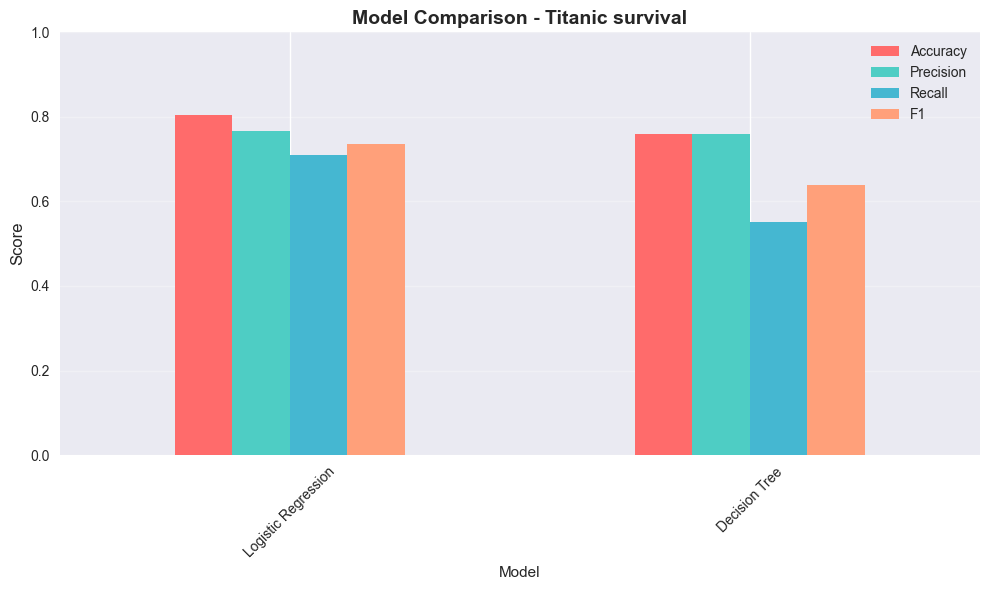

In [5]:
# WHAT: Evaluate logistic regression and a decision tree with the same four metrics and chart them.
# WHY: A fair comparison holds data, splits, and metrics constant - only the model changes.

print("\n\n4. Model Comparison")
print("-" * 70)
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5)
}
results = {}
for name, m in models.items():
    m.fit(X_train_clf_scaled, y_train_clf)
    y_pred = m.predict(X_test_clf_scaled)
    results[name] = {
        'Accuracy': accuracy_score(y_test_clf, y_pred),
        'Precision': precision_score(y_test_clf, y_pred),
        'Recall': recall_score(y_test_clf, y_pred),
        'F1': f1_score(y_test_clf, y_pred)
    }
comparison_df = pd.DataFrame(results).T
print("\nModel Comparison (Titanic survival, same test set):")
print(comparison_df.round(4))
best_f1 = comparison_df['F1'].idxmax()
winners = {metric: comparison_df[metric].idxmax() for metric in comparison_df.columns}
print(f"\nBest F1: {best_f1} ({comparison_df.loc[best_f1, 'F1']:.4f})")
print(f"Winner per metric: {winners}")
if len(set(winners.values())) == 1:
    print("Here one model wins on every metric - convenient, but not guaranteed.")
    print(f"Look at the gap: the two models are close on precision "
          f"({comparison_df['Precision'].min():.3f} vs {comparison_df['Precision'].max():.3f}) "
          f"and far apart on recall")
    print(f"({comparison_df['Recall'].min():.3f} vs {comparison_df['Recall'].max():.3f}) - "
          f"if missing a survivor were costly, that gap is the decision.")
else:
    print("Different models win on different metrics - which is why you must choose")
    print("the metric that matches the cost of each error BEFORE comparing.")

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))
comparison_df.plot(kind='bar', ax=ax, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
ax.set_title('Model Comparison - Titanic survival', fontsize=14, weight='bold')
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Model')
ax.set_ylim(0, 1)
ax.legend(loc='best')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('12_model_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Model comparison saved")
plt.show()
plt.close()

## 💬 Discuss

Measured here: 5-fold CV on California housing gives **R² 0.5784 ± 0.0489** (folds ranging
0.5488 to 0.6080). On Titanic, logistic beats the tree on **every** metric, but the gap is
**precision 0.766 vs 0.760** against **recall 0.710 vs 0.551**. Learning curves show
**train 0.605 vs validation 0.575** — a gap of 0.030.

1. The five folds span 0.549 to 0.608 — a range of 0.059 on the *same model and the same
   data*. If a colleague reports "our model gets R² = 0.61", what have they most likely
   done, and what would you ask to see?
2. A train/validation gap of only 0.030 with both scores near 0.58 is the notebook's
   evidence for **underfitting, not overfitting**. State what you would try next, and say
   what you would expect the learning curve to look like if your fix worked.
3. Netflix's winner improved the contest metric by 10.06% and was never deployed. Pick one
   metric from this notebook and describe the business decision it would *fail* to
   improve, even if you optimised it perfectly.


# 5. SUMMARY


In [6]:
# WHAT: Print the summary of evaluation techniques with the numbers this run produced.
# WHY: Cross-validation, learning curves, and multi-metric reports are the standard evaluation toolkit.

print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print(f"""
Measured in this run, on two real datasets:

  California housing ({len(X):,} block groups, linear regression)
    5-fold CV R²: {cv_scores.mean():.4f} +/- {cv_scores.std() * 2:.4f}
    Learning curves: train {train_mean[-1]:.3f} vs validation {val_mean[-1]:.3f}
      -> gap {gap:.3f}: underfitting, not overfitting

  Titanic survival ({len(X_clf)} passengers, {len(X_test_clf)} held out)
    Logistic Regression  acc {results['Logistic Regression']['Accuracy']:.3f}  F1 {results['Logistic Regression']['F1']:.3f}
    Decision Tree (d=5)  acc {results['Decision Tree']['Accuracy']:.3f}  F1 {results['Decision Tree']['F1']:.3f}

Key Concepts Covered:
1. Cross-validation techniques (and the spread between folds)
2. Learning curves (over- vs underfitting)
3. Multiple evaluation metrics
4. Model comparison on an identical split

Next Steps: Continue to Example 08 for Hyperparameter Tuning
""")


Summary

Measured in this run, on two real datasets:

  California housing (5,000 block groups, linear regression)
    5-fold CV R²: 0.5784 +/- 0.0489
    Learning curves: train 0.605 vs validation 0.575
      -> gap 0.030: underfitting, not overfitting

  Titanic survival (891 passengers, 179 held out)
    Logistic Regression  acc 0.804  F1 0.737
    Decision Tree (d=5)  acc 0.760  F1 0.639

Key Concepts Covered:
1. Cross-validation techniques (and the spread between folds)
2. Learning curves (over- vs underfitting)
3. Multiple evaluation metrics
4. Model comparison on an identical split

Next Steps: Continue to Example 08 for Hyperparameter Tuning



## 🚫 When Model Evaluation Hits a Dead End

**BEFORE**: We've learned comprehensive model evaluation techniques.

**AFTER**: We discover that model *selection* multiplies evaluation cost — and we measure exactly how much.

**Why this matters**: A single evaluation is cheap. Real workflows run hundreds of fits, and the cost is multiplicative: parameter combinations × CV folds × per-fit time.

---

### The Problem We've Discovered

We've learned:
- ✅ How to evaluate models comprehensively (cross-validation, metrics)
- ✅ How to compare models and understand performance
- ✅ How to create learning curves

**But we have a problem:**
- A single 5-fold cross-validation of a cheap model is fast (we measure it below)
- Choosing a model honestly means grid search: every parameter combination × every fold
- With a slower model (e.g. a random forest), that multiplication gets expensive quickly

**The Dead End:**
- Evaluation cost = (parameter combinations) × (CV folds) × (single-fit time)
- No guessing — the next cell times both a cheap baseline and a real grid search on this machine

---

### Demonstrating the Problem

First a cheap baseline, then a real grid search — both timed:

In [7]:
# WHAT: Time one cheap CV run, then a grid search (many fits) on 10,000 REAL network-traffic flows.
# WHY: Model selection cost = combinations x folds x per-fit time - measuring it on real data
#      motivates smarter search (next example) and hardware acceleration (Example 12).

print("\n" + "=" * 70)
print("🚫 DEMONSTRATING THE DEAD END: The Real Cost of Model Selection")
print("=" * 70)

import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Real data: CICIDS2017 - 2.3 million labelled network flows captured at the
# Canadian Institute for Cybersecurity. We read 10 numeric flow features and
# the attack label, then sample 10,000 flows.
CIC_COLS = [' Destination Port', ' Flow Duration', ' Total Fwd Packets',
            ' Total Backward Packets', 'Total Length of Fwd Packets',
            ' Total Length of Bwd Packets', ' Fwd Packet Length Mean',
            ' Bwd Packet Length Mean', 'Flow Bytes/s', ' Flow Packets/s', ' Label']
flows = pd.read_csv(DATA_DIR + 'cicids2017.csv', usecols=CIC_COLS)
flows.columns = [c.strip() for c in flows.columns]
sample = flows.sample(n=10_000, random_state=42)

# Flow-rate columns contain real infinities (zero-duration flows) - a genuine
# defect of packet capture, not something we introduced. Replace, then fill.
X_large = (sample.drop(columns=['Label'])
                 .replace([np.inf, -np.inf], np.nan)
                 .fillna(0).values)
y_large = (sample['Label'] != 'BENIGN').astype(int).values
n_samples_large = len(X_large)

print(f"\n📊 Dataset: {n_samples_large:,} real network flows × {X_large.shape[1]} features")
print(f"   Attack traffic: {y_large.mean():.1%} of flows "
      f"({int(y_large.sum()):,} of {n_samples_large:,})")
print(f"   Attack types present: "
      f"{sample.loc[sample['Label'] != 'BENIGN', 'Label'].value_counts().head(4).to_dict()}")

# --- Baseline: ONE cheap model, 5-fold CV ---
print("\n⏱️  Baseline: single LogisticRegression + 5-fold CV")
start_time = time.time()
baseline_scores = cross_val_score(LogisticRegression(max_iter=1000), X_large, y_large, cv=5)
baseline_time = time.time() - start_time
print(f"   Completed in {baseline_time:.2f} seconds (mean accuracy: {baseline_scores.mean():.4f})")
print("   → A single evaluation of a cheap model is FAST.")

# --- The real cost: grid search over a slower model ---
param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [8, None]}
n_combos = 3 * 2
n_folds = 5
n_fits = n_combos * n_folds + 1  # +1 final refit on the full data
print(f"\n⏱️  Model selection: RandomForest grid search")
print(f"   Grid: {param_grid}")
print(f"   {n_combos} combinations × {n_folds} folds (+1 final refit) = {n_fits} model fits")

start_time = time.time()
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=1),
    param_grid, cv=n_folds, n_jobs=1)  # single core: what one CPU core actually does
grid_search.fit(X_large, y_large)
grid_time = time.time() - start_time

print(f"   Completed in {grid_time:.1f} seconds ({grid_time / n_fits:.2f} s per fit)")
print(f"   Best params: {grid_search.best_params_} (CV accuracy: {grid_search.best_score_:.4f})")

print(f"\n⚠️  What we measured (this machine, single core):")
print(f"   - One cheap evaluation:   {baseline_time:.2f} s")
print(f"   - One modest grid search: {grid_time:.1f} s — about {grid_time / baseline_time:.0f}x more")

per_fit = grid_time / n_fits
print(f"\n💡 The multiplication problem (arithmetic from the measured {per_fit:.2f} s/fit):")
for combos, data_factor, label in [
        (60, 1, "bigger grid (60 combos, 5 folds)"),
        (60, 10, "bigger grid + 10x more data (100k flows)")]:
    est = combos * 5 * per_fit * data_factor
    print(f"   - {label}: {combos * 5} fits → est. ~{est / 60:.0f} minutes")
print("   (These are linear extrapolations of the measured per-fit time, NOT")
print("    measurements. Tree training scales roughly linearly in sample count.)")
print(f"   The full CICIDS2017 capture holds {len(flows):,} flows - "
      f"{len(flows) / n_samples_large:.0f}x what we just used.")

print(f"\n➡️  Solution Needed:")
print(f"   - Parallelism (n_jobs=-1) helps, but cores are limited")
print(f"   - Smarter search (random / Bayesian) beats exhaustive grids - Example 08")
print(f"   - GPU-accelerated ML libraries (cuML, XGBoost GPU) attack the per-fit time")
print(f"   - This leads us to Example 12: CPU vs GPU for ML")
print("\n" + "=" * 70)


🚫 DEMONSTRATING THE DEAD END: The Real Cost of Model Selection



📊 Dataset: 10,000 real network flows × 10 features
   Attack traffic: 24.2% of flows (2,417 of 10,000)
   Attack types present: {'DoS Hulk': 1018, 'PortScan': 701, 'DDoS': 523, 'DoS GoldenEye': 38}

⏱️  Baseline: single LogisticRegression + 5-fold CV


   Completed in 0.64 seconds (mean accuracy: 0.8541)
   → A single evaluation of a cheap model is FAST.

⏱️  Model selection: RandomForest grid search
   Grid: {'n_estimators': [50, 100, 200], 'max_depth': [8, None]}
   6 combinations × 5 folds (+1 final refit) = 31 model fits


   Completed in 13.7 seconds (0.44 s per fit)
   Best params: {'max_depth': None, 'n_estimators': 100} (CV accuracy: 0.9921)

⚠️  What we measured (this machine, single core):
   - One cheap evaluation:   0.64 s
   - One modest grid search: 13.7 s — about 21x more

💡 The multiplication problem (arithmetic from the measured 0.44 s/fit):
   - bigger grid (60 combos, 5 folds): 300 fits → est. ~2 minutes
   - bigger grid + 10x more data (100k flows): 300 fits → est. ~22 minutes
   (These are linear extrapolations of the measured per-fit time, NOT
    measurements. Tree training scales roughly linearly in sample count.)
   The full CICIDS2017 capture holds 2,300,825 flows - 230x what we just used.

➡️  Solution Needed:
   - Parallelism (n_jobs=-1) helps, but cores are limited
   - Smarter search (random / Bayesian) beats exhaustive grids - Example 08
   - GPU-accelerated ML libraries (cuML, XGBoost GPU) attack the per-fit time
   - This leads us to Example 12: CPU vs GPU for ML



## 💬 Discuss

Timed on this machine, on 10,000 real CIC-IDS2017 network flows (24.2% attack traffic):
one 5-fold CV of logistic regression took **0.64 s** (accuracy 0.854); a 6-combination
random-forest grid search — **31 fits** — took **13.7 s** at **0.44 s per fit**, and reached
CV accuracy **0.9921**.

1. 0.854 to 0.9921 is a large jump for 21× the compute. Was it worth it *here*? Now suppose
   this is an intrusion-detection system where a missed attack costs far more than a false
   alarm — does accuracy even answer the question? Name the metric you would grid-search on
   instead.
2. The notebook extrapolates: 300 fits on 100k flows ≈ 22 minutes, and says plainly this is
   arithmetic, not a measurement. What could make that estimate badly wrong in either
   direction?
3. You have a fixed compute budget. Spend it on (a) a bigger hyperparameter grid, (b) more
   cross-validation folds, or (c) more training data. Rank them for this problem and defend
   the ranking.


### What We Need Next

**The Solution**: We need to attack the per-fit time:
- **Parallel CPU search**: `n_jobs=-1` divides the fits across cores — helpful, but bounded by core count
- **GPU-accelerated ML**: libraries like cuML and XGBoost's GPU mode parallelize the fit itself
- **A note on numbers**: vendors publish order-of-magnitude GPU training speedups on large datasets; those are *their published benchmarks*, not something this notebook measured

**Where this dead end leads:**
- Example 08 (next) runs grid and random search for real — the workflow side of the cost problem
- Example 12 examines GPU acceleration for ML — the hardware side
- The measured multiplication above (combinations × folds × per-fit time) is exactly the cost both of them attack

## ⚠️ Where this breaks

- **Cross-validation gives you a spread, not a certificate.** ±0.0489 here is the *variance
  of the estimate*, and it assumes the folds are exchangeable draws from the population you
  will deploy on. For time series, grouped records, or spatial data — California block
  groups are spatially correlated — plain K-fold is optimistic, sometimes badly.
- **Selecting on cross-validation is itself overfitting, one level up.** Every model you
  compare on the same CV score consumes some of that data's ability to tell you the truth.
  Try fifty models and the winner's CV score is biased upward. The honest structure is
  three-way: train, validation (for selection), and a test set touched **once**.
- **Every metric encodes a value judgement, and defaults hide it.** F1 weights precision
  and recall equally, which is a claim that a false alarm and a miss cost the same. They
  almost never do. `fbeta_score` lets you say so out loud.
- **Learning curves diagnose bias and variance, not correctness.** A model can underfit
  beautifully consistently and still be predicting the wrong quantity — the censored
  California target from Unit 2 lesson 06 is unaffected by anything on this page.
- **The assumption that must hold: the labels are right.** Every metric in this notebook
  compares predictions to labels and assumes the labels are truth. In the fraud data,
  "not fraud" means "not *detected* as fraud" — some of those 284,315 negatives are
  undetected frauds, and no evaluation here can see them.
- **A grid search reports its winner without reporting how close the runner-up was.**
  `best_params_` is a point estimate chosen from noisy CV scores; when the top few
  combinations are within one standard error, prefer the simpler model.
- **Cheaper alternative:** before spending 13.7 s (or 22 minutes) on model selection, spend
  30 seconds on a baseline — majority class, or a single feature. Half the model-selection
  effort in industry is spent beating something that was never checked, and lesson 06's
  99.827% dummy is the reason.


## 📚 References

1. Stone, M. (1974). *Cross-Validatory Choice and Assessment of Statistical Predictions*. Journal of the Royal Statistical Society, Series B, 36(2), 111-147.
2. Raschka, S. (2018). *Model Evaluation, Model Selection, and Algorithm Selection in Machine Learning*. arXiv preprint. <https://arxiv.org/abs/1811.12808>
3. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning*, 2nd ed., Ch. 5 (Resampling Methods). Springer. <https://www.statlearning.com>
4. Erickson, N., Purucker, L., Tschalzev, A., et al. (2025). *TabArena: A Living Benchmark for Machine Learning on Tabular Data*. arXiv:2506.16791. <https://arxiv.org/abs/2506.16791>
5. Ghosh et al. (2026). *Evaluation Cards: An Interpretive Layer for AI Evaluation Reporting*. arXiv:2606.09809. <https://arxiv.org/abs/2606.09809>
